<a href="https://colab.research.google.com/github/Rudragehlot/Building-Surprise-prediction-algo/blob/main/Hyperparameter_Tuning_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tuning the hyper-parameters of an estimator (to improve the performance)

Why **Hyperparameter** Tuning?

Models have hyperparameters (set before training), e.g.:

Decision Tree → max_depth, min_samples_split

SVM → C, kernel

👉 Goal: Find the best combination that gives highest performance.

In [5]:
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [6]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [7]:
model= RandomForestClassifier()

In [8]:
patam_grid={'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
  }

In [9]:
grid_search= GridSearchCV(estimator=model, param_grid=patam_grid, cv=5, scoring="accuracy")

In [10]:
grid_search.fit(X,y)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [11]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
0.9666666666666668


# basic roandomizedSearchCV

In [12]:
from sklearn.model_selection import RandomizedSearchCV

In [13]:
param_dist={
    'n_estimators': [50, 100,200,300,500],
    'max_depth': [None, 10, 20,30],
    'min_samples_split': [2, 5, 10,15],
}

In [15]:
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42
)

In [16]:
random_search.fit(X,y)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(),
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'min_samples_split': [2, 5, 10, 15],
                                        'n_estimators': [50, 100, 200, 300,
                                                         500]},
                   random_state=42, scoring='accuracy')

In [17]:
print(random_search.best_params_)
print(random_search.best_score_)

{'n_estimators': 50, 'min_samples_split': 2, 'max_depth': None}
0.9666666666666668


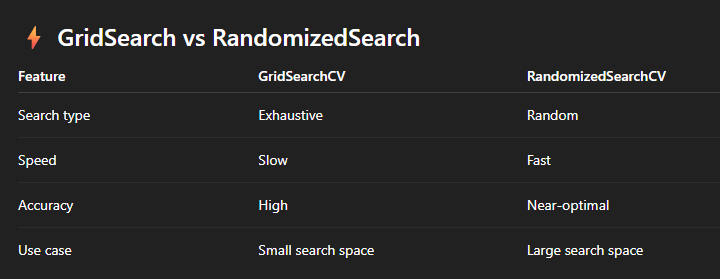

*Hyperparameter Optimization + Cross Validation*

It prevents:-

*🗿Overfitting

*🏃Underfitting